# Simulating price and return processes: Lognormal prices and AR(1) returns

> Based on MITx Mathematical Methods for Quantitative Finance — Unit 2.

In this notebook, we will simulate two stochastic processes:

1. A lognormal price process, where log-returns are normally distributed.
2. An AR(1) return process, where returns depend on their previous values.

The goal is to understand how logarithms and the lognormal distribution help model asset price dynamics.

We will also use the AR(1) model to study mean reversion empirically and analyze how autocorrelation changes when we modify the model parameters.

In [63]:
import numpy as np
from scipy.stats import binom
from matplotlib import pyplot as plt
from math import sqrt
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from scipy import stats

## Simulating a lognormal price process

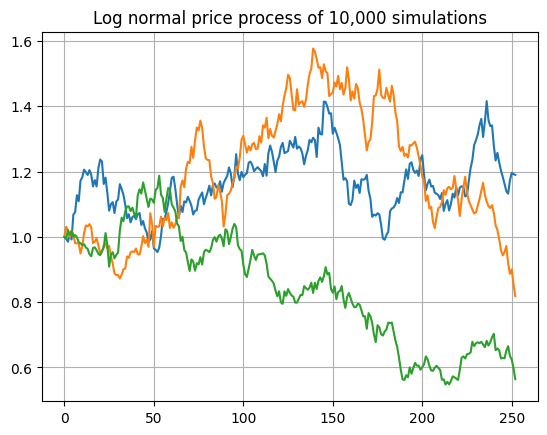

In [20]:
Nt = 252  # trading days
Np = int(1e4)  # 10000 paths
sigma = 0.4  # set annualized volatility of 40%
mu = 0.1  # annualized expected return of 10%
dt = 1 / 252  # Time step scale factor (we want daily steps)

# we want to creat log normal returns r_t = ln(Pt/P_t-1)

z = np.random.normal(
    size=(Nt, Np)
)  # here we create random normal shocks of Np * Nt shape in order to give the stochastic essence

r = mu * dt + z * sigma * np.sqrt(
    dt
)  # now we transform those shocks, note the similairty to a generalized random walk process

# we are definign price of 1, we can change it with other prices
s = np.zeros((Nt + 1, Np))

for i in range(1, len(s)):

    s[i] = (
        s[i - 1] + r[i - 1]
    )  # we fill the values with the previous value + our generalized normal shocks

P = np.exp(
    s
)  # note that here P is P_t / P_t-1, we have recreated the same formula but with the logaritmic way

plt.plot(P[:, 0:3])
plt.title("Log normal price process of 10,000 simulations")
plt.grid()
plt.show()

In [28]:
# lets analyze the theorical and empical metrics

R = (
    P[Nt] - 1
)  # now we want the simplest returns of the last simulated period of all the possible paths
empirical_mean = np.mean(R)  # we compute the empirical mean
theorical_mean = np.exp(mu + sigma**2 / 2) - 1

print(f"Theorical mean: {theorical_mean} vs empirical mean: {empirical_mean}")

empirical_std = np.std(R)
theoretical_std = np.sqrt(np.exp(2 * mu + sigma**2) * (np.exp(sigma**2) - 1))

print(f"Theorical std: {theoretical_std} vs empirical std: {empirical_std}")

Theorical mean: 0.19721736312181015 vs empirical mean: 0.1955825781054692
Theorical std: 0.4986965361204609 vs empirical std: 0.4956495777021501


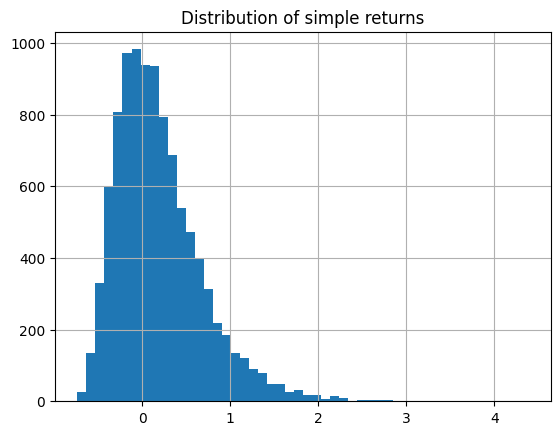

In [33]:
# lets analyze the distributions, qq plots and cdf
plt.hist(R, bins=50)
plt.title("Distribution of simple returns")
plt.grid()
plt.show()

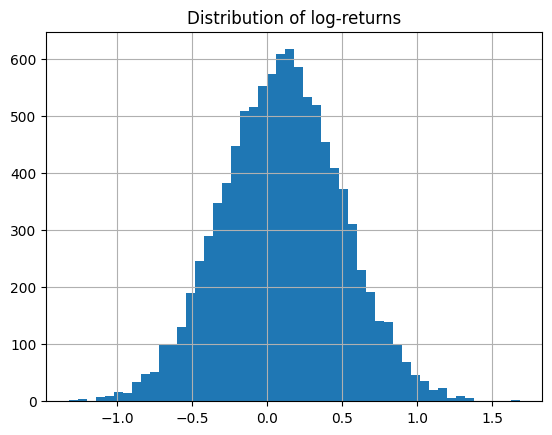

In [37]:
plt.hist(np.log(1 + R), bins=50)
plt.title("Distribution of log-returns")
plt.grid()
plt.show()

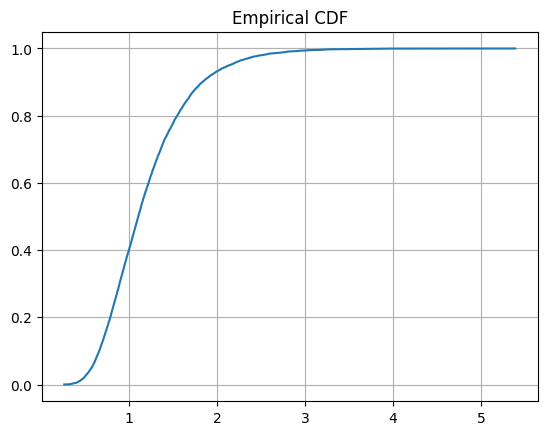

In [38]:
ecdf = ECDF(1 + R)

plt.plot(ecdf.x, ecdf.y)
plt.title("Empirical CDF")
plt.grid()
plt.show()

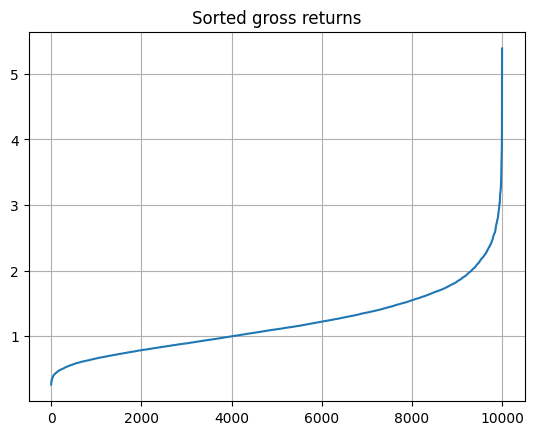

In [39]:
plt.plot(np.sort(1 + R))
plt.title("Sorted gross returns")
plt.grid()
plt.show()

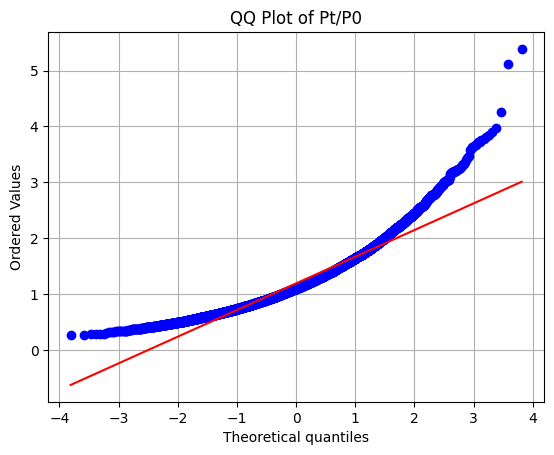

In [ ]:
stats.probplot((1 + R), dist="norm", plot=plt)

plt.title("QQ Plot of Pt/P0")  # P follows a log normal distribution
plt.grid()
plt.show()

## Simulating an AR(1)-style simple return process

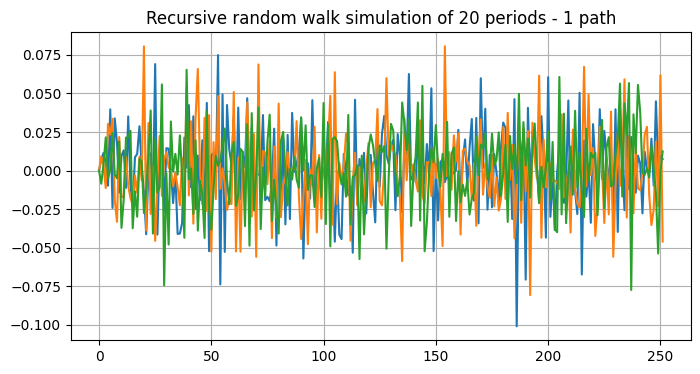

In [56]:
lmbda = 0.4
mu = 0.1

R = np.zeros((Nt, Np))

# we simulate IID gaussian shocks (noise) again but now different from z (tandardize)
epsilon = np.random.normal(size=(Nt, Np), loc=0, scale=sigma * np.sqrt(dt))
# it has its own scaled shocks

for index in range(1, Nt):

    R[index] = (1 + lmbda) * (mu * dt) - lmbda * R[index - 1] + epsilon[index]

plt.figure(figsize=(8, 4))
plt.plot(R[:, 0:3])
plt.title("Recursive random walk simulation of 20 periods - 1 path")
plt.grid()
plt.show()

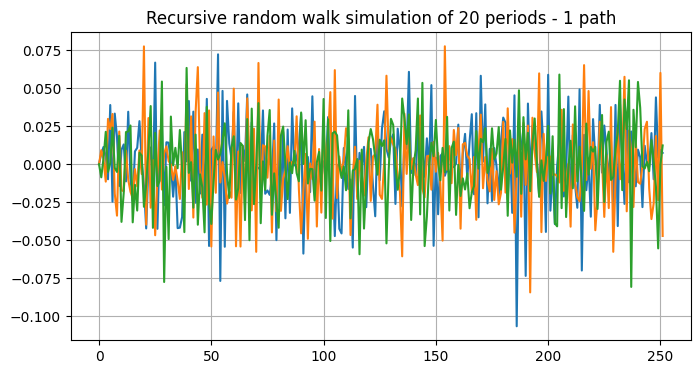

In [58]:
r = np.log(1 + R)
plt.figure(figsize=(8, 4))
plt.plot(r[:, 0:3])
plt.title("Recursive random walk simulation of 20 periods - 1 path")
plt.grid()
plt.show()

[ 1.00000000e+00 -4.68871500e-01  2.96416685e-01 -1.37076536e-01
  6.12818890e-02 -6.23861864e-03 -3.27891465e-04  1.47821471e-02
 -4.57955848e-02  1.18622829e-01 -1.16000719e-01  2.94877552e-02
  5.18849187e-02  1.04290908e-02 -8.15944391e-03  3.30088405e-02
 -3.64635643e-02  4.14824549e-02 -1.03766411e-02 -1.48919563e-01
  7.25549052e-02 -3.91070190e-02 -1.99421012e-02 -2.09532747e-02
 -1.93500098e-02]


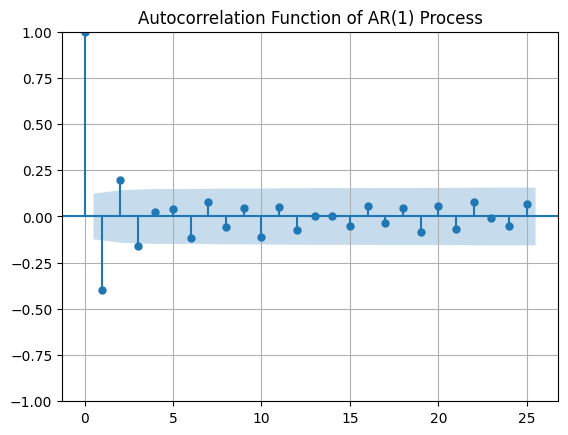

In [64]:
acf_values = acf(R[:, 0])

print(acf_values)


plot_acf(R[:, 1])
plt.title("Autocorrelation Function of AR(1) Process")
plt.grid()
plt.show()

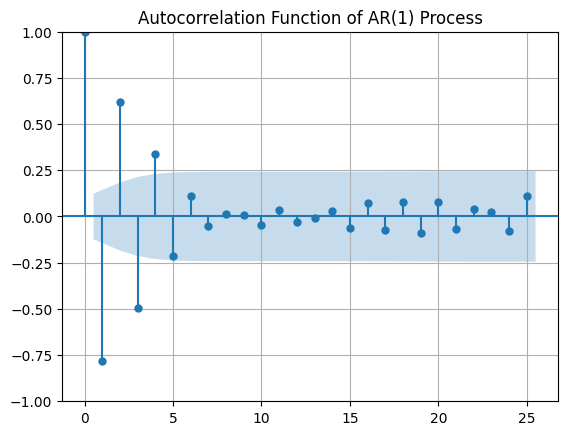

In [65]:
lmbda = 0.8
for index in range(1, Nt):

    R[index] = (1 + lmbda) * (mu * dt) - lmbda * R[index - 1] + epsilon[index]


plot_acf(R[:, 1])
plt.title("Autocorrelation Function of AR(1) Process")
plt.grid()
plt.show()